# Multi-Scale Convolutional Neural Network (MSCNN) Architecture

This notebook implements the Multi-Scale Convolutional Neural Network (MSCNN) architecture for Stokes profile inversion, as described in the thesis. The architecture is based on the work of [Jiang et al. (2019)](https://doi.org/10.1016/j.measurement.2019.07.009) for fault diagnosis, adapted here for solar spectropolarimetric inversions.

## Architecture Overview

The MSCNN processes Stokes profiles (I, V) at multiple spectral resolutions through:
1. **Coarse-graining**: Average pooling at scales $s \in \mathcal{S} = \{1, 2, 3\}$
2. **Convolutional feature extraction**: Two-layer Conv1D blocks with ReLU and MaxPool
3. **Feature concatenation**: Combining multi-scale representations
4. **Fully-connected layers**: Four hidden layers with dropout for uncertainty quantification
5. **Output**: Atmospheric parameters (T, Vz, Bz) at 21 optical depth nodes

## 1. Import Required Libraries

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from typing import List, Tuple, Dict, Optional

# For architecture visualization
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Check device availability
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Plotting configuration
plt.rcParams.update({
    'figure.figsize': (12, 6),
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 14,
    'legend.fontsize': 10,
})

Using device: cuda


## 2. Define Coarse-Grain Module

The coarse-grain module implements the average pooling operation that sub-samples the input Stokes profiles at different scales:

$$\boldsymbol{x}^{(s)} = \text{AvgPool}_{s}(\boldsymbol{x}_\text{input}), \quad s \in \mathcal{S}$$

This is achieved using the `unfold` operation to extract windows of size $s$, followed by averaging over each window. This preserves the local structure while reducing the spectral resolution proportionally to the scale factor.

In [2]:
class CoarseGrain(nn.Module):
    """
    Coarse-graining module that applies average pooling at a specified scale.
    
    For an input of length L, this produces an output of length L // scale
    by averaging non-overlapping windows of size `scale`.
    
    Parameters
    ----------
    scale : int
        The pooling scale factor. Must be a positive integer.
        
    Example
    -------
    >>> cg = CoarseGrain(scale=2)
    >>> x = torch.randn(4, 2, 112)  # (batch, channels, length)
    >>> y = cg(x)
    >>> print(y.shape)  # torch.Size([4, 2, 56])
    """
    
    def __init__(self, scale: int) -> None:
        super().__init__()
        if scale < 1:
            raise ValueError(f"Scale must be positive, got {scale}")
        self.scale = scale
    
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Apply coarse-graining to the input tensor.
        
        Parameters
        ----------
        x : torch.Tensor
            Input tensor of shape (batch, channels, length)
            
        Returns
        -------
        torch.Tensor
            Coarse-grained tensor of shape (batch, channels, length // scale)
        """
        if self.scale == 1:
            return x
        
        # unfold extracts sliding windows: (batch, channels, n_windows, window_size)
        # We use non-overlapping windows (step = scale)
        unfolded = x.unfold(dimension=2, size=self.scale, step=self.scale)
        
        # Average over the window dimension (last dimension)
        return unfolded.mean(dim=-1)
    
    def extra_repr(self) -> str:
        return f"scale={self.scale}"


# Demonstrate the coarse-graining operation
print("=" * 60)
print("CoarseGrain Module Demonstration")
print("=" * 60)

# Create sample input (simulating Stokes I, V profiles)
batch_size = 2
n_channels = 2  # I and V
input_length = 112  # Hinode wavelength sampling

x_demo = torch.randn(batch_size, n_channels, input_length)
print(f"\nInput shape: {x_demo.shape}")

# Apply coarse-graining at different scales
for scale in [1, 2, 3, 4]:
    cg = CoarseGrain(scale=scale)
    y = cg(x_demo)
    print(f"Scale {scale}: Output shape = {y.shape} (length: {input_length} → {y.shape[2]})")

CoarseGrain Module Demonstration

Input shape: torch.Size([2, 2, 112])
Scale 1: Output shape = torch.Size([2, 2, 112]) (length: 112 → 112)
Scale 2: Output shape = torch.Size([2, 2, 56]) (length: 112 → 56)
Scale 3: Output shape = torch.Size([2, 2, 37]) (length: 112 → 37)
Scale 4: Output shape = torch.Size([2, 2, 28]) (length: 112 → 28)


## 3. Define Convolutional Block

The convolutional block implements a two-layer architecture:

$$\boldsymbol{z}_1^{(s)} = \text{ReLU}\left(\sum_{c=1}^{C_\text{in}} \mathbf{K}_1^{(s,c)} * \boldsymbol{x}^{(s)} + \boldsymbol{b}_1^{(s)}\right)$$

$$\boldsymbol{z}_2^{(s)} = \text{ReLU}\left(\sum_{c=1}^{C_\text{in}} \mathbf{K}_2^{(s,c)} * \text{MaxPool}(\boldsymbol{z}_1^{(s)}) + \boldsymbol{b}_2^{(s)}\right)$$

Each layer consists of:
- **Conv1d**: Kernel size $k=5$, stride 1, no padding
- **ReLU activation**
- **MaxPool1d**: Pool size 2

In [3]:
class ConvBlock(nn.Module):
    """
    Two-layer convolutional block with ReLU activations and max pooling.
    
    Architecture:
        Conv1d(in_channels, c1_filters, k) → ReLU → MaxPool(2)
        Conv1d(c1_filters, c2_filters, k) → ReLU → MaxPool(2)
    
    Parameters
    ----------
    in_channels : int
        Number of input channels (default: 2 for Stokes I, V)
    c1_filters : int
        Number of filters in the first convolutional layer (default: 16)
    c2_filters : int
        Number of filters in the second convolutional layer (default: 32)
    kernel_size : int
        Size of the convolutional kernels (default: 5)
    stride : int
        Stride of the convolutions (default: 1)
    padding : int
        Padding applied to convolutions (default: 0)
    pool_size : int
        Size of the max pooling windows (default: 2)
    """
    
    def __init__(
        self,
        *,
        in_channels: int = 2,
        c1_filters: int = 16,
        c2_filters: int = 32,
        kernel_size: int = 5,
        stride: int = 1,
        padding: int = 0,
        pool_size: int = 2,
    ) -> None:
        super().__init__()
        
        self.kernel_size = kernel_size
        self.stride = stride
        self.padding = padding
        self.pool_size = pool_size
        
        # First convolutional layer: Conv → ReLU → MaxPool
        self.c1 = nn.Sequential(
            nn.Conv1d(
                in_channels=in_channels,
                out_channels=c1_filters,
                kernel_size=kernel_size,
                stride=stride,
                padding=padding,
            ),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=pool_size),
        )
        
        # Second convolutional layer: Conv → ReLU → MaxPool
        self.c2 = nn.Sequential(
            nn.Conv1d(
                in_channels=c1_filters,
                out_channels=c2_filters,
                kernel_size=kernel_size,
                stride=stride,
                padding=padding,
            ),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=pool_size),
        )
    
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Forward pass through the convolutional block.
        
        Parameters
        ----------
        x : torch.Tensor
            Input tensor of shape (batch, in_channels, length)
            
        Returns
        -------
        torch.Tensor
            Output tensor of shape (batch, c2_filters, reduced_length)
        """
        x = self.c1(x)
        x = self.c2(x)
        return x


# Demonstrate the convolutional block
print("=" * 60)
print("ConvBlock Module Demonstration")
print("=" * 60)

conv_block = ConvBlock(in_channels=2, c1_filters=16, c2_filters=32)
print(f"\nConvBlock architecture:")
print(conv_block)

# Test with sample input
x_demo = torch.randn(4, 2, 112)
print(f"\nInput shape: {x_demo.shape}")

# Trace through the layers
with torch.no_grad():
    z1 = conv_block.c1(x_demo)
    print(f"After first Conv+ReLU+Pool: {z1.shape}")
    z2 = conv_block.c2(z1)
    print(f"After second Conv+ReLU+Pool: {z2.shape}")

ConvBlock Module Demonstration

ConvBlock architecture:
ConvBlock(
  (c1): Sequential(
    (0): Conv1d(2, 16, kernel_size=(5,), stride=(1,))
    (1): ReLU()
    (2): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (c2): Sequential(
    (0): Conv1d(16, 32, kernel_size=(5,), stride=(1,))
    (1): ReLU()
    (2): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
)

Input shape: torch.Size([4, 2, 112])
After first Conv+ReLU+Pool: torch.Size([4, 16, 54])
After second Conv+ReLU+Pool: torch.Size([4, 32, 25])


## 4. Define Multi-Scale Feature Mapping

The multi-scale feature mapping combines coarse-graining and convolutional processing across multiple scales:

$$\boldsymbol{z}_\text{concat} = \text{Concat}_{s \in \mathcal{S}}\left(\text{MaxPool}(\boldsymbol{z}_2^{(s)})\right)$$

For each scale $s \in \mathcal{S} = \{1, 2, 3\}$:
1. Apply coarse-graining to reduce spectral resolution
2. Process through the convolutional block
3. Concatenate all scale representations along the spatial dimension

In [4]:
class MultiScaleFeatureMapping(nn.Module):
    """
    Multi-scale feature extraction module.
    
    Processes input at multiple spectral resolutions and concatenates
    the resulting feature maps.
    
    Parameters
    ----------
    scales : list[int]
        List of scale factors for coarse-graining (default: [1, 2, 3])
    in_channels : int
        Number of input channels (default: 2)
    c1_filters : int
        Filters in the first conv layer (default: 16)
    c2_filters : int
        Filters in the second conv layer (default: 32)
    kernel_size : int
        Convolutional kernel size (default: 5)
    stride : int
        Convolutional stride (default: 1)
    padding : int
        Convolutional padding (default: 0)
    pool_size : int
        Max pooling size (default: 2)
    """
    
    def __init__(
        self,
        *,
        scales: List[int] = None,
        in_channels: int = 2,
        c1_filters: int = 16,
        c2_filters: int = 32,
        kernel_size: int = 5,
        stride: int = 1,
        padding: int = 0,
        pool_size: int = 2,
    ) -> None:
        super().__init__()
        
        if scales is None:
            scales = [1, 2, 3]
        
        self.scales = scales
        self.c2_filters = c2_filters
        
        # Create coarse-graining modules for each scale
        self.coarse_grains = nn.ModuleDict({
            f"scale_{s}": CoarseGrain(scale=s) for s in scales
        })
        
        # Single shared convolutional block for all scales
        # (Alternative: separate blocks per scale)
        self.conv_block = ConvBlock(
            in_channels=in_channels,
            c1_filters=c1_filters,
            c2_filters=c2_filters,
            kernel_size=kernel_size,
            stride=stride,
            padding=padding,
            pool_size=pool_size,
        )
    
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Process input at multiple scales and concatenate feature maps.
        
        Parameters
        ----------
        x : torch.Tensor
            Input tensor of shape (batch, in_channels, length)
            
        Returns
        -------
        torch.Tensor
            Concatenated features of shape (batch, c2_filters, total_length)
        """
        # Initialize empty tensor for concatenation
        feature_maps = torch.empty(
            (x.size(0), self.c2_filters, 0),
            dtype=torch.float32,
            device=x.device
        )
        
        # Process each scale
        for s in self.scales:
            # Coarse-grain the input
            x_cg = self.coarse_grains[f"scale_{s}"](x)
            
            # Apply convolutional block
            z = self.conv_block(x_cg)
            
            # Concatenate along the spatial dimension
            feature_maps = torch.cat((feature_maps, z), dim=-1)
        
        return feature_maps


# Demonstrate multi-scale feature mapping
print("=" * 60)
print("MultiScaleFeatureMapping Module Demonstration")
print("=" * 60)

msfm = MultiScaleFeatureMapping(scales=[1, 2, 3])
print(f"\nMultiScaleFeatureMapping with scales = {msfm.scales}")

x_demo = torch.randn(4, 2, 112)
print(f"\nInput shape: {x_demo.shape}")

with torch.no_grad():
    features = msfm(x_demo)
    print(f"Output feature map shape: {features.shape}")
    
    # Show contribution from each scale
    print("\nFeature map lengths per scale:")
    for s in [1, 2, 3]:
        x_cg = msfm.coarse_grains[f"scale_{s}"](x_demo)
        z = msfm.conv_block(x_cg)
        print(f"  Scale {s}: Input {x_cg.shape[2]} → Features {z.shape[2]}")

MultiScaleFeatureMapping Module Demonstration

MultiScaleFeatureMapping with scales = [1, 2, 3]

Input shape: torch.Size([4, 2, 112])
Output feature map shape: torch.Size([4, 32, 42])

Feature map lengths per scale:
  Scale 1: Input 112 → Features 25
  Scale 2: Input 56 → Features 11
  Scale 3: Input 37 → Features 6


## 5. Define Linear Block with Dropout

The linear block implements four fully-connected hidden layers with ReLU activations:

$$\boldsymbol{y}_j = \text{ReLU}(\mathbf{w}_j \cdot \boldsymbol{y}_{j-1} + \boldsymbol{b}_j), \quad j = 1, \ldots, 4$$

$$\boldsymbol{y}_\text{output} = \mathbf{w}_\text{output} \cdot \boldsymbol{y}_4 + \boldsymbol{b}_\text{output}$$

**Dropout** is included after each ReLU activation for:
1. **Regularization** during training
2. **Uncertainty quantification** via Monte Carlo Dropout during inference

In [5]:
class LinearBlock(nn.Module):
    """
    Fully-connected block with multiple hidden layers and optional dropout.
    
    Architecture:
        Linear(in, hidden) → ReLU → Dropout (repeated n_layers times)
        Linear(hidden, out)
    
    Parameters
    ----------
    in_features : int
        Size of the input feature vector (from flattened conv features)
    out_features : int
        Size of the output (default: 63 = 3 params × 21 depths)
    n_layers : int
        Number of hidden layers (default: 4)
    dropout_rate : float
        Dropout probability (default: 0.2)
    """
    
    def __init__(
        self,
        *,
        in_features: int,
        out_features: int,
        n_layers: int = 4,
        dropout_rate: float = 0.2,
    ) -> None:
        super().__init__()
        
        self.dropout_rate = dropout_rate
        self.n_layers = n_layers
        
        # Build hidden layers
        self.layers = nn.ModuleList()
        for i in range(n_layers):
            layer = nn.Sequential(
                nn.Linear(in_features=in_features, out_features=in_features),
                nn.ReLU(),
                nn.Dropout(p=dropout_rate) if dropout_rate > 0 else nn.Identity()
            )
            self.layers.append(layer)
        
        # Output layer (no activation)
        self.output_layer = nn.Linear(in_features=in_features, out_features=out_features)
    
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Forward pass through the linear block.
        
        Parameters
        ----------
        x : torch.Tensor
            Input tensor of shape (batch, in_features)
            
        Returns
        -------
        torch.Tensor
            Output tensor of shape (batch, out_features)
        """
        for layer in self.layers:
            x = layer(x)
        return self.output_layer(x)


# Demonstrate the linear block
print("=" * 60)
print("LinearBlock Module Demonstration")
print("=" * 60)

linear_block = LinearBlock(
    in_features=1280,
    out_features=63,
    n_layers=4,
    dropout_rate=0.2
)

print(f"\nLinearBlock architecture:")
print(f"  Input features: 1280")
print(f"  Hidden layers: 4 × (Linear(1280, 1280) → ReLU → Dropout(0.2))")
print(f"  Output features: 63")

# Count parameters
total_params = sum(p.numel() for p in linear_block.parameters())
print(f"  Total parameters: {total_params:,}")

# Test forward pass
x_demo = torch.randn(4, 1280)
with torch.no_grad():
    y = linear_block(x_demo)
    print(f"\nInput shape: {x_demo.shape}")
    print(f"Output shape: {y.shape}")

LinearBlock Module Demonstration

LinearBlock architecture:
  Input features: 1280
  Hidden layers: 4 × (Linear(1280, 1280) → ReLU → Dropout(0.2))
  Output features: 63
  Total parameters: 6,639,423

Input shape: torch.Size([4, 1280])
Output shape: torch.Size([4, 63])


## 6. Assemble Complete MSCNN Model

The complete MSCNNInversionModel combines all components:

1. **MultiScaleFeatureMapping**: Extract multi-scale convolutional features
2. **Flatten**: Convert 2D feature maps to 1D vector
3. **LinearBlock**: Process through fully-connected layers with dropout

The model supports two inference modes:
- **Deterministic**: Standard forward pass (dropout disabled)
- **Stochastic**: Monte Carlo Dropout for uncertainty quantification

In [6]:
def _conv1d_output_length(
    input_size: int,
    kernel_size: int,
    stride: int = 1,
    padding: int = 0
) -> int:
    """
    Compute the output length of a 1D convolution layer.
    
    Formula: L_out = floor((L_in + 2*padding - kernel_size) / stride) + 1
    """
    return (input_size - kernel_size + 2 * padding) // stride + 1


class MSCNNInversionModel(nn.Module):
    """
    Multi-Scale Convolutional Neural Network for Stokes Profile Inversion.
    
    This model processes Stokes I and V profiles to predict atmospheric
    parameters (T, Vz, Bz) at multiple optical depth nodes.
    
    Architecture:
        Input (batch, 2, 112) → CoarseGrain at scales [1,2,3]
        → Conv1d(2,16,k=5) → ReLU → MaxPool(2)
        → Conv1d(16,32,k=5) → ReLU → MaxPool(2)
        → Concatenate scales → Flatten
        → Linear(1280,1280) → ReLU → Dropout (×4)
        → Linear(1280, 63) → Output
    
    Parameters
    ----------
    scales : list[int]
        Scale factors for coarse-graining (default: [1, 2, 3])
    in_channels : int
        Number of Stokes parameters (default: 2 for I, V)
    c1_filters : int
        Filters in first conv layer (default: 16)
    c2_filters : int
        Filters in second conv layer (default: 32)
    kernel_size : int
        Convolution kernel size (default: 5)
    pool_size : int
        Max pooling size (default: 2)
    n_linear_layers : int
        Number of hidden FC layers (default: 4)
    output_features : int
        Output size (default: 63 = 3 × 21)
    input_length : int
        Input wavelength samples (default: 112)
    dropout_rate : float
        Dropout probability (default: 0.2)
    """
    
    def __init__(
        self,
        *,
        scales: List[int] = None,
        in_channels: int = 2,
        c1_filters: int = 16,
        c2_filters: int = 32,
        kernel_size: int = 5,
        stride: int = 1,
        padding: int = 0,
        pool_size: int = 2,
        n_linear_layers: int = 4,
        output_features: int = 63,
        input_length: int = 112,
        dropout_rate: float = 0.2,
    ) -> None:
        super().__init__()
        
        if scales is None:
            scales = [1, 2, 3]
        
        self.scales = scales
        self.input_length = input_length
        self.output_features = output_features
        self.dropout_rate = dropout_rate
        
        # Multi-scale feature mapping
        self.msfm = MultiScaleFeatureMapping(
            scales=scales,
            in_channels=in_channels,
            c1_filters=c1_filters,
            c2_filters=c2_filters,
            kernel_size=kernel_size,
            stride=stride,
            padding=padding,
            pool_size=pool_size,
        )
        
        # Compute flatten size
        self.flatten_size = self._compute_flatten_size(
            input_length=input_length,
            scales=scales,
            kernel_size=kernel_size,
            stride=stride,
            padding=padding,
            pool_size=pool_size,
            c2_filters=c2_filters,
        )
        
        # Flatten layer
        self.flatten = nn.Flatten()
        
        # Linear block
        self.linear_block = LinearBlock(
            in_features=self.flatten_size,
            out_features=output_features,
            n_layers=n_linear_layers,
            dropout_rate=dropout_rate,
        )
    
    def _compute_flatten_size(
        self,
        input_length: int,
        scales: List[int],
        kernel_size: int,
        stride: int,
        padding: int,
        pool_size: int,
        c2_filters: int,
    ) -> int:
        """
        Compute the size of the flattened feature vector.
        
        For each scale s:
            1. Coarse-grain: L_s = L // s
            2. Conv1 + Pool: L_s' = (L_s - k + 1) // pool
            3. Conv2 + Pool: L_s'' = (L_s' - k + 1) // pool
        
        Total: sum over scales of (L_s'' × c2_filters)
        """
        total_features = 0
        
        for s in scales:
            # Coarse-grained length
            length = input_length // s
            
            # After first Conv + Pool
            length = _conv1d_output_length(length, kernel_size, stride, padding)
            length = length // pool_size
            
            # After second Conv + Pool
            length = _conv1d_output_length(length, kernel_size, stride, padding)
            length = length // pool_size
            
            total_features += length
        
        return total_features * c2_filters
    
    def forward(
        self,
        x: torch.Tensor,
        stochastic_generation: bool = False,
        stochastic_steps: int = 30
    ) -> torch.Tensor:
        """
        Forward pass through the MSCNN model.
        
        Parameters
        ----------
        x : torch.Tensor
            Input Stokes profiles of shape (batch, 2, 112)
        stochastic_generation : bool
            If True, perform MC Dropout inference (default: False)
        stochastic_steps : int
            Number of stochastic forward passes (default: 30)
            
        Returns
        -------
        torch.Tensor
            If stochastic_generation=False: (batch, 63)
            If stochastic_generation=True: (stochastic_steps, batch, 63)
        """
        # Multi-scale feature extraction
        features = self.msfm(x)
        
        # Flatten
        features = self.flatten(features)
        
        # Stochastic inference mode (MC Dropout)
        if stochastic_generation and not self.training:
            # Enable dropout during inference
            self.linear_block.train()
            
            predictions = []
            for _ in range(stochastic_steps):
                pred = self.linear_block(features)
                predictions.append(pred.unsqueeze(0))
            
            # Restore eval mode
            self.linear_block.eval()
            
            # Stack: (stochastic_steps, batch, output_features)
            return torch.cat(predictions, dim=0)
        
        # Deterministic forward pass
        return self.linear_block(features)


# Instantiate the complete model
print("=" * 60)
print("Complete MSCNNInversionModel")
print("=" * 60)

model = MSCNNInversionModel(
    scales=[1, 2, 3],
    in_channels=2,
    c1_filters=16,
    c2_filters=32,
    kernel_size=5,
    pool_size=2,
    n_linear_layers=4,
    output_features=63,
    input_length=112,
    dropout_rate=0.2,
)

print(f"\nModel Configuration:")
print(f"  Scales: {model.scales}")
print(f"  Input: ({2}, {112}) → Stokes I, V profiles")
print(f"  Output: {model.output_features} = 3 params × 21 optical depths")
print(f"  Flatten size: {model.flatten_size}")
print(f"  Dropout rate: {model.dropout_rate}")

Complete MSCNNInversionModel

Model Configuration:
  Scales: [1, 2, 3]
  Input: (2, 112) → Stokes I, V profiles
  Output: 63 = 3 params × 21 optical depths
  Flatten size: 1344
  Dropout rate: 0.2


## 7. Compute Feature Map Dimensions

This section provides a detailed breakdown of how the feature map dimensions evolve through the network, leading to the flatten size of 1280 neurons.

In [7]:
def compute_dimension_trace(
    input_length: int = 112,
    scales: List[int] = None,
    kernel_size: int = 5,
    pool_size: int = 2,
    c1_filters: int = 16,
    c2_filters: int = 32,
) -> Dict:
    """
    Trace the dimension transformations through the MSCNN architecture.
    
    Returns a detailed breakdown of sizes at each stage.
    """
    if scales is None:
        scales = [1, 2, 3]
    
    trace = {
        'input_length': input_length,
        'scales': {},
        'total_spatial': 0,
        'flatten_size': 0,
    }
    
    for s in scales:
        scale_trace = {'scale': s}
        
        # Coarse-graining
        L = input_length // s
        scale_trace['after_coarse_grain'] = L
        
        # Conv1 (no padding)
        L = _conv1d_output_length(L, kernel_size)
        scale_trace['after_conv1'] = L
        
        # Pool1
        L = L // pool_size
        scale_trace['after_pool1'] = L
        
        # Conv2
        L = _conv1d_output_length(L, kernel_size)
        scale_trace['after_conv2'] = L
        
        # Pool2
        L = L // pool_size
        scale_trace['after_pool2'] = L
        
        scale_trace['final_spatial'] = L
        trace['scales'][s] = scale_trace
        trace['total_spatial'] += L
    
    trace['flatten_size'] = trace['total_spatial'] * c2_filters
    
    return trace


# Compute and display dimension trace
print("=" * 60)
print("Feature Map Dimension Trace")
print("=" * 60)

trace = compute_dimension_trace(
    input_length=112,
    scales=[1, 2, 3],
    kernel_size=5,
    pool_size=2,
    c1_filters=16,
    c2_filters=32,
)

print(f"\nInput length: {trace['input_length']}")
print(f"\n{'Scale':<8} {'Coarse':<10} {'Conv1':<10} {'Pool1':<10} {'Conv2':<10} {'Pool2':<10}")
print("-" * 58)

for s, data in trace['scales'].items():
    print(f"{s:<8} {data['after_coarse_grain']:<10} {data['after_conv1']:<10} "
          f"{data['after_pool1']:<10} {data['after_conv2']:<10} {data['after_pool2']:<10}")

print("-" * 58)
print(f"\nTotal spatial dimension: {trace['total_spatial']}")
print(f"Feature channels (c2_filters): 32")
print(f"Flatten size: {trace['total_spatial']} × 32 = {trace['flatten_size']}")

# Verify with model
assert trace['flatten_size'] == model.flatten_size, "Mismatch in flatten size calculation!"
print(f"\n✓ Verified: flatten_size = {model.flatten_size}")

Feature Map Dimension Trace

Input length: 112

Scale    Coarse     Conv1      Pool1      Conv2      Pool2     
----------------------------------------------------------
1        112        108        54         50         25        
2        56         52         26         22         11        
3        37         33         16         12         6         
----------------------------------------------------------

Total spatial dimension: 42
Feature channels (c2_filters): 32
Flatten size: 42 × 32 = 1344

✓ Verified: flatten_size = 1344


## 8. Model Instantiation and Parameter Count

Let's create the model with default hyperparameters and count the total number of trainable parameters.

In [8]:
# Create model with default configuration
model = MSCNNInversionModel(
    scales=[1, 2, 3],
    in_channels=2,
    c1_filters=16,
    c2_filters=32,
    kernel_size=5,
    pool_size=2,
    n_linear_layers=4,
    output_features=63,  # 3 parameters × 21 optical depth nodes
    input_length=112,
    dropout_rate=0.2,
).to(device)

print("=" * 60)
print("Model Parameter Summary")
print("=" * 60)

# Count parameters by module
def count_parameters(module, name=""):
    """Count trainable parameters in a module."""
    total = sum(p.numel() for p in module.parameters() if p.requires_grad)
    return total

# Detailed breakdown
print(f"\n{'Module':<35} {'Parameters':>15}")
print("-" * 50)

# Convolutional layers
conv_params = count_parameters(model.msfm.conv_block)
print(f"{'ConvBlock (shared)':<35} {conv_params:>15,}")

# Linear layers
for i, layer in enumerate(model.linear_block.layers):
    layer_params = count_parameters(layer)
    print(f"{'Linear Layer ' + str(i+1):<35} {layer_params:>15,}")

output_params = count_parameters(model.linear_block.output_layer)
print(f"{'Output Layer':<35} {output_params:>15,}")

print("-" * 50)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"{'TOTAL':<35} {total_params:>15,}")

# Memory estimation
param_memory_mb = total_params * 4 / (1024 ** 2)  # 4 bytes per float32
print(f"\nParameter memory: {param_memory_mb:.2f} MB")

# Model architecture summary
print("\n" + "=" * 60)
print("Architecture Summary")
print("=" * 60)
print(model)

Model Parameter Summary

Module                                   Parameters
--------------------------------------------------
ConvBlock (shared)                            2,768
Linear Layer 1                            1,807,680
Linear Layer 2                            1,807,680
Linear Layer 3                            1,807,680
Linear Layer 4                            1,807,680
Output Layer                                 84,735
--------------------------------------------------
TOTAL                                     7,318,223

Parameter memory: 27.92 MB

Architecture Summary
MSCNNInversionModel(
  (msfm): MultiScaleFeatureMapping(
    (coarse_grains): ModuleDict(
      (scale_1): CoarseGrain(scale=1)
      (scale_2): CoarseGrain(scale=2)
      (scale_3): CoarseGrain(scale=3)
    )
    (conv_block): ConvBlock(
      (c1): Sequential(
        (0): Conv1d(2, 16, kernel_size=(5,), stride=(1,))
        (1): ReLU()
        (2): MaxPool1d(kernel_size=2, stride=2, padding=0, dilatio

## 9. Forward Pass Demonstration

Let's verify the model works correctly with a dummy input representing Stokes I and V profiles.

In [9]:
# Create dummy Stokes input
batch_size = 8
n_channels = 2  # Stokes I and V
n_wavelengths = 112  # Hinode wavelength sampling

# Random input simulating normalized Stokes profiles
dummy_input = torch.randn(batch_size, n_channels, n_wavelengths, device=device)

print("=" * 60)
print("Forward Pass Demonstration")
print("=" * 60)

print(f"\nInput shape: {dummy_input.shape}")
print(f"  - Batch size: {batch_size}")
print(f"  - Channels: {n_channels} (Stokes I, V)")
print(f"  - Wavelength points: {n_wavelengths}")

# Set model to evaluation mode
model.eval()

# Forward pass
with torch.no_grad():
    output = model(dummy_input)

print(f"\nOutput shape: {output.shape}")
print(f"  - Batch size: {output.shape[0]}")
print(f"  - Features: {output.shape[1]} = 3 params × 21 depths")

# Interpret output structure
n_depths = 21
n_params = 3

print(f"\nOutput interpretation:")
print(f"  - Temperature (T):     indices [0:{n_depths}]")
print(f"  - LOS Velocity (Vz):   indices [{n_depths}:{2*n_depths}]")
print(f"  - LOS Magnetic (Bz):   indices [{2*n_depths}:{3*n_depths}]")

# Show sample output statistics
print(f"\nSample output statistics (normalized values):")
T_out = output[:, :n_depths]
Vz_out = output[:, n_depths:2*n_depths]
Bz_out = output[:, 2*n_depths:]

print(f"  T:  mean={T_out.mean():.4f}, std={T_out.std():.4f}")
print(f"  Vz: mean={Vz_out.mean():.4f}, std={Vz_out.std():.4f}")
print(f"  Bz: mean={Bz_out.mean():.4f}, std={Bz_out.std():.4f}")

Forward Pass Demonstration

Input shape: torch.Size([8, 2, 112])
  - Batch size: 8
  - Channels: 2 (Stokes I, V)
  - Wavelength points: 112

Output shape: torch.Size([8, 63])
  - Batch size: 8
  - Features: 63 = 3 params × 21 depths

Output interpretation:
  - Temperature (T):     indices [0:21]
  - LOS Velocity (Vz):   indices [21:42]
  - LOS Magnetic (Bz):   indices [42:63]

Sample output statistics (normalized values):
  T:  mean=-0.0064, std=0.0192
  Vz: mean=0.0045, std=0.0230
  Bz: mean=-0.0022, std=0.0173


## 10. Monte Carlo Dropout Inference

Monte Carlo Dropout enables uncertainty quantification by performing multiple stochastic forward passes with dropout enabled during inference. This provides:

1. **Mean prediction**: Average over all stochastic passes
2. **Prediction uncertainty**: Standard deviation across passes

The uncertainty estimates help identify regions where the model is less confident, which is particularly valuable for:
- Active regions with complex magnetic topologies
- Weak-field pixels where signal-to-noise is low
- Out-of-distribution samples

Monte Carlo Dropout Inference

Configuration:
  - MC samples: 30
  - Dropout rate: 0.2
  - Input shape: torch.Size([1, 2, 112])

MC predictions shape: torch.Size([30, 1, 63])
  - MC samples: 30
  - Batch: 1
  - Features: 63

Prediction statistics:
  Mean shape: torch.Size([1, 63])
  Std shape: torch.Size([1, 63])


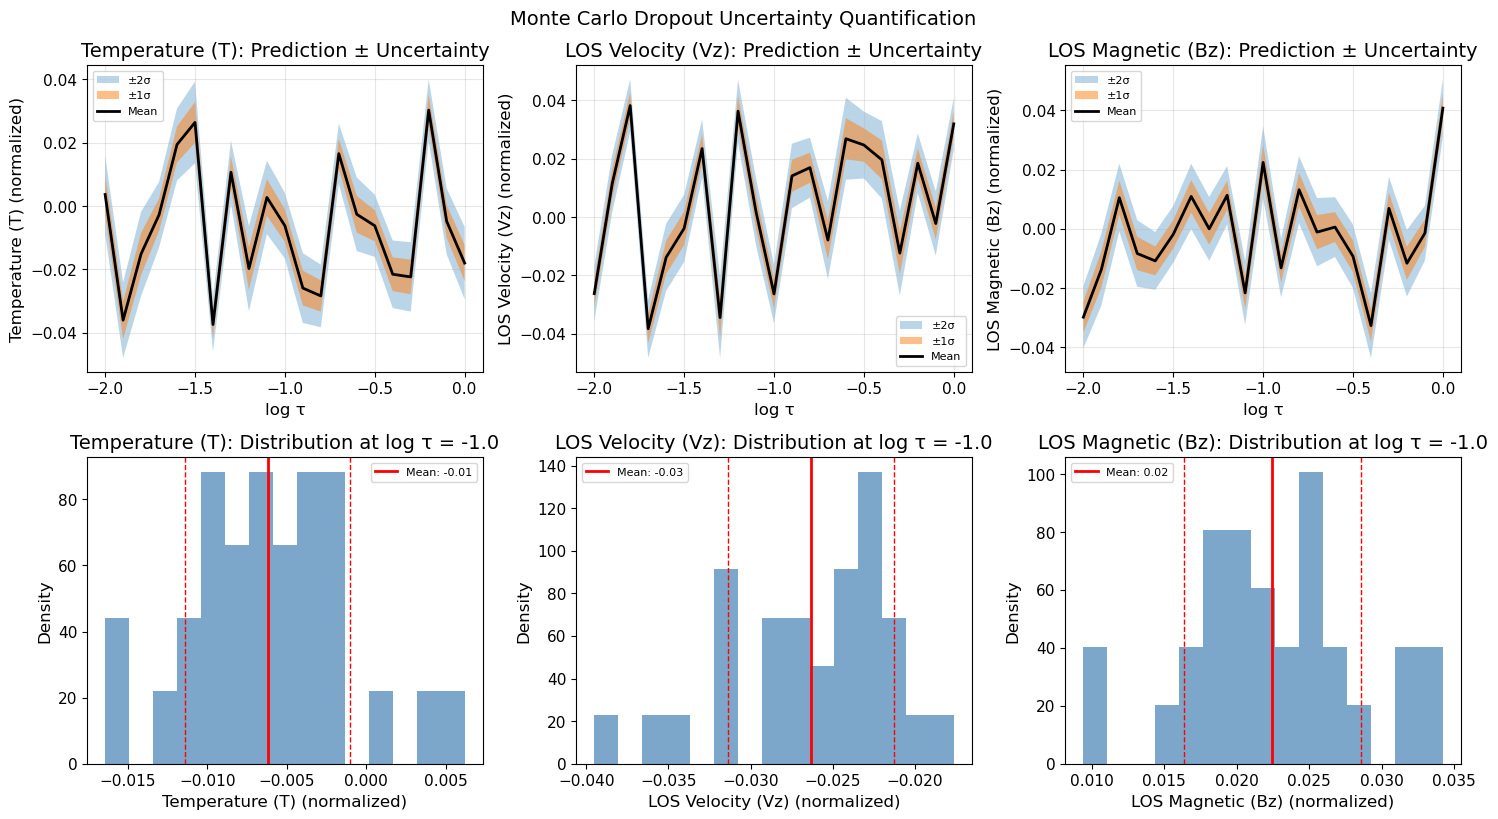


Uncertainty Summary
  T: mean σ = 0.0055, max σ = 0.0067
  Vz: mean σ = 0.0056, max σ = 0.0073
  Bz: mean σ = 0.0054, max σ = 0.0061

✓ MC Dropout successfully demonstrated!
  → Mean predictions provide best estimate
  → Standard deviations quantify prediction uncertainty


In [10]:
# Monte Carlo Dropout demonstration
print("=" * 60)
print("Monte Carlo Dropout Inference")
print("=" * 60)

# Number of stochastic forward passes
n_mc_samples = 30

# Sample input (single pixel for visualization)
sample_input = torch.randn(1, 2, 112, device=device)

print(f"\nConfiguration:")
print(f"  - MC samples: {n_mc_samples}")
print(f"  - Dropout rate: {model.dropout_rate}")
print(f"  - Input shape: {sample_input.shape}")

# Stochastic forward pass
model.eval()  # Set to eval mode
with torch.no_grad():
    # This internally enables dropout for stochastic_steps passes
    mc_predictions = model(
        sample_input,
        stochastic_generation=True,
        stochastic_steps=n_mc_samples
    )

print(f"\nMC predictions shape: {mc_predictions.shape}")
print(f"  - MC samples: {mc_predictions.shape[0]}")
print(f"  - Batch: {mc_predictions.shape[1]}")
print(f"  - Features: {mc_predictions.shape[2]}")

# Compute statistics
mc_mean = mc_predictions.mean(dim=0)  # (batch, features)
mc_std = mc_predictions.std(dim=0)    # (batch, features)

print(f"\nPrediction statistics:")
print(f"  Mean shape: {mc_mean.shape}")
print(f"  Std shape: {mc_std.shape}")

# Visualize uncertainty for one sample
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

param_names = ['Temperature (T)', 'LOS Velocity (Vz)', 'LOS Magnetic (Bz)']
logtau = np.arange(-2.0, 0.1, 0.1)
n_depths = 21

for i, (name, ax_mean, ax_dist) in enumerate(zip(param_names, axes[0], axes[1])):
    start_idx = i * n_depths
    end_idx = (i + 1) * n_depths
    
    mean_vals = mc_mean[0, start_idx:end_idx].cpu().numpy()
    std_vals = mc_std[0, start_idx:end_idx].cpu().numpy()
    all_samples = mc_predictions[:, 0, start_idx:end_idx].cpu().numpy()
    
    # Top row: Mean prediction with uncertainty
    ax_mean.fill_between(logtau, mean_vals - 2*std_vals, mean_vals + 2*std_vals,
                         alpha=0.3, label='±2σ')
    ax_mean.fill_between(logtau, mean_vals - std_vals, mean_vals + std_vals,
                         alpha=0.5, label='±1σ')
    ax_mean.plot(logtau, mean_vals, 'k-', lw=2, label='Mean')
    ax_mean.set_xlabel('log τ')
    ax_mean.set_ylabel(f'{name} (normalized)')
    ax_mean.set_title(f'{name}: Prediction ± Uncertainty')
    ax_mean.legend(loc='best', fontsize=8)
    ax_mean.grid(True, alpha=0.3)
    
    # Bottom row: Distribution at specific optical depth
    mid_idx = n_depths // 2  # Middle optical depth
    samples_at_mid = all_samples[:, mid_idx]
    ax_dist.hist(samples_at_mid, bins=15, density=True, alpha=0.7, color='steelblue')
    ax_dist.axvline(mean_vals[mid_idx], color='red', lw=2, label=f'Mean: {mean_vals[mid_idx]:.2f}')
    ax_dist.axvline(mean_vals[mid_idx] - std_vals[mid_idx], color='red', ls='--', lw=1)
    ax_dist.axvline(mean_vals[mid_idx] + std_vals[mid_idx], color='red', ls='--', lw=1)
    ax_dist.set_xlabel(f'{name} (normalized)')
    ax_dist.set_ylabel('Density')
    ax_dist.set_title(f'{name}: Distribution at log τ = {logtau[mid_idx]:.1f}')
    ax_dist.legend(loc='best', fontsize=8)

plt.tight_layout()
plt.suptitle('Monte Carlo Dropout Uncertainty Quantification', fontsize=14, y=1.02)
plt.savefig('./notebooks_images/mscnn_mc_dropout_demo.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary statistics
print("\n" + "=" * 60)
print("Uncertainty Summary")
print("=" * 60)

for i, name in enumerate(['T', 'Vz', 'Bz']):
    start_idx = i * n_depths
    end_idx = (i + 1) * n_depths
    mean_uncertainty = mc_std[0, start_idx:end_idx].mean().item()
    max_uncertainty = mc_std[0, start_idx:end_idx].max().item()
    print(f"  {name}: mean σ = {mean_uncertainty:.4f}, max σ = {max_uncertainty:.4f}")

print("\n✓ MC Dropout successfully demonstrated!")
print("  → Mean predictions provide best estimate")
print("  → Standard deviations quantify prediction uncertainty")